# 10.6.1 预测时域与硬约束

## 学习目标与先修知识

把小型离散行动MPC写成可枚举问题并检查不可行。

先修：10.5有限时域优化、第8.4章约束与可行性、第7篇初始状态（state）估计。

## 具体问题

无约束最优输入（input）可能越过执行或状态上限。若限制每一步可能的行动，能否明确写出预测轨迹（trajectory）、代价和不可行状态，而不是把最后一个旧解伪装成当前解？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

用最小例 x=0、两步、动作集合{−1,0,1}，先列出9条候选序列的第一步结果。

In [2]:
actions=[-1.,0.,1.];print([(u0,u1,u0) for u0 in actions for u1 in actions])

[(-1.0, -1.0, -1.0), (-1.0, 0.0, -1.0), (-1.0, 1.0, -1.0), (0.0, -1.0, 0.0), (0.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, -1.0, 1.0), (1.0, 0.0, 1.0), (1.0, 1.0, 1.0)]


## 模型假设

为了能完整枚举，教学MPC将输入限制为有限离散集合。预测动力学 $x_{t+1}=a x_t+b u_t$，每一步预测（one-step-ahead prediction）后继须满足 $lower\le x\le upper$；阶段代价 $q(x_t-target)^2+r u_t^2$，终端代价 $q_f(x_N-target)^2$。相同成本按行动序列字典序确定一个可复核答案。该离散行动问题不同于一般连续输入MPC。

## 数学解释与推导

时域N的决策变量是 $u_0,\ldots,u_{N-1}$。对每条候选序列，从已知初态递推预测状态，检查每个后继的硬约束，再计算
$$J=\sum_{t=0}^{N-1}\{q(x_t-r)^2+\rho u_t^2\}+q_f(x_N-r)^2.$$
这里以 $\rho$ 记题目参数（parameter）r的输入权重，避免与目标r混淆。若没有任何完整可行序列，就返回不可行；只执行最优序列第一项，下一时刻得到新状态估计后重新求解。

硬约束与罚项不同：软化约束会改变问题，可能允许超限。枚举能为这个小型离散任务给出精确参照，但候选数是 $|\mathcal U|^N$，一般高维连续MPC需要专门求解器、终止条件与可行性证据。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def discrete_mpc(state, a, b, target, q, r, terminal, actions, horizon, lower, upper):
    """Exact enumeration of a small *discrete-action* MPC, not continuous MPC."""
    best = None
    for sequence in itertools.product(actions, repeat=horizon):
        x = state
        cost = 0.0
        path = [x]
        for u in sequence:
            cost += q * (x - target) ** 2 + r * u * u
            x = a * x + b * u
            path.append(x)
            if not lower <= x <= upper:
                break
        else:
            cost += terminal * (x - target) ** 2
            candidate = (cost, sequence, path)
            if best is None or candidate[:2] < best[:2]:
                best = candidate
    if best is None:
        return 'infeasible', None, None, []
    cost, sequence, path = best
    return 'optimal', sequence[0], cost, path

## 对照实验

显示固定初态下所有可行序列的成本，并把不可行候选明确标出。接着把初态推到边界外，观察返回值如何变化。

| 行动序列 | 成本 | 约束 |
| --- | --- | --- |
| (-1.0, -1.0) | None | 不可行 |
| (-1.0, 0.0) | 31.1 | 可行 |
| (-1.0, 1.0) | 21.2 | 可行 |
| (0.0, -1.0) | 26.1 | 可行 |
| (0.0, 0.0) | 16 | 可行 |
| (0.0, 1.0) | 10.1 | 可行 |
| (1.0, -1.0) | 13.2 | 可行 |
| (1.0, 0.0) | 7.1 | 可行 |
| (1.0, 1.0) | 5.2 | 可行 |

最优状态、首步、成本、轨迹： optimal 1.0 5.199999999999999 [0.0, 1.0, 2.0]
上界外且只能非负行动： ('infeasible', None, None, [])


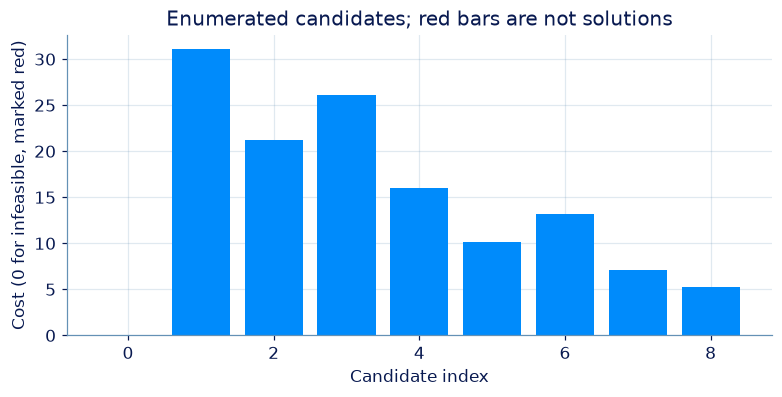

In [4]:
state=0.;actions=[-1.,0.,1.];rows=[]
for seq in itertools.product(actions,repeat=2):
    x=state;cost=0.;ok=True
    for u in seq:
        cost+=(x-2.)**2+.1*u*u;x=x+u
        if not -1.<=x<=2.:ok=False;break
    if ok:cost+=2*(x-2.)**2
    rows.append((str(seq),round(cost,3) if ok else None,'可行' if ok else '不可行'))
status,first,cost,path=discrete_mpc(state,1.,1.,2.,1.,.1,2.,actions,2,-1.,2.)
display(Markdown(show_table(['行动序列','成本','约束'],rows)))
print('最优状态、首步、成本、轨迹：',status,first,cost,path)
print('上界外且只能非负行动：',discrete_mpc(3.,1.,1.,0.,1.,1.,1.,[0.,1.],2,-1.,2.))
fig,ax=plt.subplots(figsize=(7,3.5));ax.bar(range(len(rows)),[r[1] if r[1] is not None else 0 for r in rows],color=[BLUE if r[1] is not None else PINK for r in rows]);ax.set(xlabel='Candidate index',ylabel='Cost (0 for infeasible, marked red)',title='Enumerated candidates; red bars are not solutions');plt.show()

## 结果解释

可行候选需要完成全部两步及终端约束检查。红色条只标记不可行，不应把其高度0当作代价0或优秀方案。边界外例没有任何可行行动，因此返回不可行状态。

### 独立核对

用独立的两重循环直接取成本最小的可行候选，与通用枚举实现比对；再核对每个返回预测后继均在硬界内。

In [5]:
best=min((c,ast.literal_eval(seq)) for seq,c,flag in rows if flag=='可行')
assert status=='optimal' and np.isclose(cost,best[0]) and first==best[1][0]
assert all(-1<=x<=2 for x in path[1:])
assert discrete_mpc(3.,1.,1.,0.,1.,1.,1.,[0.,1.],2,-1.,2.)[0]=='infeasible'
print('独立枚举、硬约束及不可行边界一致。')

独立枚举、硬约束及不可行边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：求解一个小型硬约束 MPC

在离散行动集上枚举预测时域的每条行动序列，动力学 x_next=ax+bu；每步后要求 lower≤x≤upper。最小化各步q(x−target)²+r u²与终端terminal(x_N−target)²。成本相等选字典序较小的序列。

**函数与代码模板**

```python
def solve(
    state: float,
    a: float,
    b: float,
    target: float,
    q: float,
    r: float,
    terminal: float,
    actions: list[float],
    horizon: int,
    lower: float,
    upper: float,
) -> tuple[str, float | None, float | None, list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `float` | 当前状态（state）。 | U |
| `a` | `float` | 离散保持系数。 | 1 |
| `b` | `float` | 输入（input）作用系数。 | U/输入 |
| `target` | `float` | 目标状态。 | U |
| `q` | `float` | 阶段跟踪权重，非负。 | 代价/U² |
| `r` | `float` | 输入权重，非负。 | 代价/输入² |
| `terminal` | `float` | 终端跟踪权重，非负。 | 代价/U² |
| `actions` | `list[float]` | 允许的离散输入，已升序且互异。 | 输入单位 |
| `horizon` | `int` | 预测步数。 | 步 |
| `lower` | `float` | 预测状态下界。 | U |
| `upper` | `float` | 预测状态上界。 | U |

**返回值**

按以下顺序返回元组：(status, first_action, minimum_cost, predicted_states)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `status` | `str` | optimal或infeasible。 | 不适用 |
| `first_action` | <code>float &#124; None</code> | 最优序列首个输入；不可行时None。 | 输入单位 |
| `minimum_cost` | <code>float &#124; None</code> | 最小总代价；不可行时None。 | 代价 |
| `predicted_states` | `list[float]` | 最优预测状态，含初态；不可行时空列表。 | U |

**计算规则**

对每条序列先累计阶段代价，再推进状态并检查硬约束；完整可行时加终端代价。没有可行序列返回(infeasible,None,None,[])。最优解在题给的离散行动集合内选择。

**约束与边界**

- actions含2—7个有限实数、升序互异；1≤horizon≤4；候选序列至多2401个；lower<upper，初态可位于范围外。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 当前状态（state）。 | 0 | U |
| a | 离散保持系数。 | 1 | 1 |
| b | 输入（input）作用系数。 | 1 | U/输入 |
| target | 目标状态。 | 2 | U |
| q | 阶段跟踪权重，非负。 | 1 | 代价/U² |
| r | 输入权重，非负。 | 0.1 | 代价/输入² |
| terminal | 终端跟踪权重，非负。 | 2 | 代价/U² |
| actions | 允许的离散输入，已升序且互异。 | [-1.0, 0.0, 1.0] | 输入单位 |
| horizon | 预测步数。 | 2 | 步 |
| lower | 预测状态下界。 | -1 | U |
| upper | 预测状态上界。 | 2 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = 0.0
a = 1.0
b = 1.0
target = 2.0
q = 1.0
r = 0.1
terminal = 2.0
actions = [-1.0, 0.0, 1.0]
horizon = 2
lower = -1.0
upper = 2.0

result = solve(state, a, b, target, q, r, terminal, actions, horizon, lower, upper)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| status | optimal或infeasible。 | optimal | 不适用 |
| first_action | 最优序列首个输入；不可行时None。 | 1 | 输入单位 |
| minimum_cost | 最小总代价；不可行时None。 | 5.2 | 代价 |
| predicted_states | 最优预测状态，含初态；不可行时空列表。 | [0.0, 1.0, 2.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ('optimal',
                   1.0,
                   5.199999999999999,
                   [0.0, 1.0, 2.0])
```

**样例解释**

第二例起点在上界外且所有允许动作非负，后继不可行；第三例成本并列，应选−1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：求解一个小型硬约束 MPC](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-discrete-mpc)

### 第 2 题 · 单项选择题：滚动时域的关键动作

MPC 在当前时刻得到长度N的可行预测序列。下一时刻通常怎样使用它？

- **A.** 只执行首步，取得新观测（observation）/估计后重新求解。
- **B.** 把整段序列无条件执行完。
- **C.** 一次可行证明所有未来场景都可行。
- **D.** 预测序列就是已经发生的真实轨迹（trajectory）。

[作答：滚动时域的关键动作](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-mpc-receding)

### 第 3 题 · 单项选择题：硬约束与软约束

将 x≤xmax 的硬约束改成超限惩罚的软约束。哪项正确？

- **A.** 优化问题已改变，求解器可能选择违反原硬界的解。
- **B.** 罚项足够大就对任意数值情形绝对不违反。
- **C.** 软约束与执行器物理限幅完全同义。
- **D.** 原先不可行的硬问题自动证明系统安全。

[作答：硬约束与软约束](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-hard-soft)

### 第 4 题 · 单项选择题：求解失败要如实报告

小型 MPC 因硬约束不可行。哪项处理符合本教材证据要求？

- **A.** 明确返回不可行并单独说明备用策略适用域。
- **B.** 把上一次最优输入（input）沿用且报告本次求解成功。
- **C.** 偷偷扩大约束却仍称原问题可行。
- **D.** 令代价为0并把失败场景从评价中删除。

[作答：求解失败要如实报告](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-infeasible-truth)

**进一步阅读**

[MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。